**1. Установка необходимых библиотек и импорт.**

In [ ]:
import sys

print(sys.executable)
print(sys.version)

%pip install --upgrade pip

%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost requests optuna phik 

%pip install nltk

%pip install imbalanced-learn


d:\my_project\my_project_venv\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
import os
import urllib.parse
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

In [3]:
%pip install -q ydata-profiling
%pip install ydata-profiling[notebook]

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
from ydata_profiling import ProfileReport

**2. Загрузка данных.**

In [5]:
import pandas as pd

def load_fixed_csv(filename):
    records = []
    bad_lines = []

    with open(filename, 'r', encoding='utf-8-sig') as f:
        next(f)  # заголовок
        for i, raw in enumerate(f, start=2):
            line = raw.rstrip('\n')
            if not line.strip():
                continue

            # Определяем разделитель: последний из ';' или ','
            pos_comma = line.rfind(',')
            pos_semicolon = line.rfind(';')
            pos = max(pos_comma, pos_semicolon)

            if pos == -1:
                bad_lines.append((i, line))
                continue

            text = line[:pos].strip().strip('"')
            label_str = line[pos + 1:].strip().strip('"')

            # Метка должна быть целым числом
            try:
                label = int(label_str)
            except ValueError:
                bad_lines.append((i, line))
                continue

            records.append((text, label))

    df = pd.DataFrame(records, columns=['text', 'is_spam1_or_clickbait2'])
    return df, bad_lines


df, bad_lines = load_fixed_csv('df.csv')


print("\nИнформация о датасете")
df.info()

print()
print(f"Размер датасета: {df.shape}")

print(f"Проблемных строк: {len(bad_lines)}")
df.columns = df.columns.str.strip()

print("\nНазвания столбцов")
print(df.columns.tolist())

print("\nПроверка на пропуски")
display(df.isnull().sum())

print("\nПервые десять строк датасета")
display(df.head(10))

print("\nПроверка данных на наличие дубликатов")
display(df.duplicated().sum())

print("\nРаспределение меток:")
print(df['is_spam1_or_clickbait2'].value_counts().sort_index())


Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69317 entries, 0 to 69316
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text                    69317 non-null  object
 1   is_spam1_or_clickbait2  69317 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB

Размер датасета: (69317, 2)
Проблемных строк: 0

Названия столбцов
['text', 'is_spam1_or_clickbait2']

Проверка на пропуски


text                      0
is_spam1_or_clickbait2    0
dtype: int64


Первые десять строк датасета


,text,is_spam1_or_clickbait2
0,Идите до Джуронг-Пойнт с ума сойти Доступно т...,0
1,Ладно лар Шучу с тобой чувак,0
2,Ты не можешь так рано говорить хо Ты можешь уж...,0
3,Нет я не думаю что он учится в USF он живет гд...,0
4,Привет дорогая прошло уже 3 недели а ответа н...,1
5,Я скоро буду дома и я больше не хочу сегодня г...,0
6,Я искала правильные слова чтобы поблагодарить ...,0
7,XXXMobileMovieClub Чтобы использовать свой кр...,1
8,О к я смотрю здесь,0
9,Эх ты помнишь как пишется его имя Да я помню О...,0



Проверка данных на наличие дубликатов


np.int64(3144)


Распределение меток:
is_spam1_or_clickbait2
0    46216
1    21502
2     1599
Name: count, dtype: int64


**3. Детальный отчет по данным ydata_profiling.**

In [6]:
# Генерация отчёта.
profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:10<00:00,  5.10s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
# Сохраняем исходный размер датасета ПЕРЕД удалением дубликатов
initial_shape = df.shape

# Удаляем полные дубликаты (совпадающие и по тексту, и по метке)
df = df.drop_duplicates()

# Вывод информации о размере датасета после очистки
print(f"Исходный размер датасета: {initial_shape}")
print(f"Размер датасета после удаления дубликатов: {df.shape}")
print(f"Удалено строк: {initial_shape[0] - df.shape[0]}")

Исходный размер датасета: (69317, 2)
Размер датасета после удаления дубликатов: (66173, 2)
Удалено строк: 3144


**4. Визуализация дисбаланса классов.**

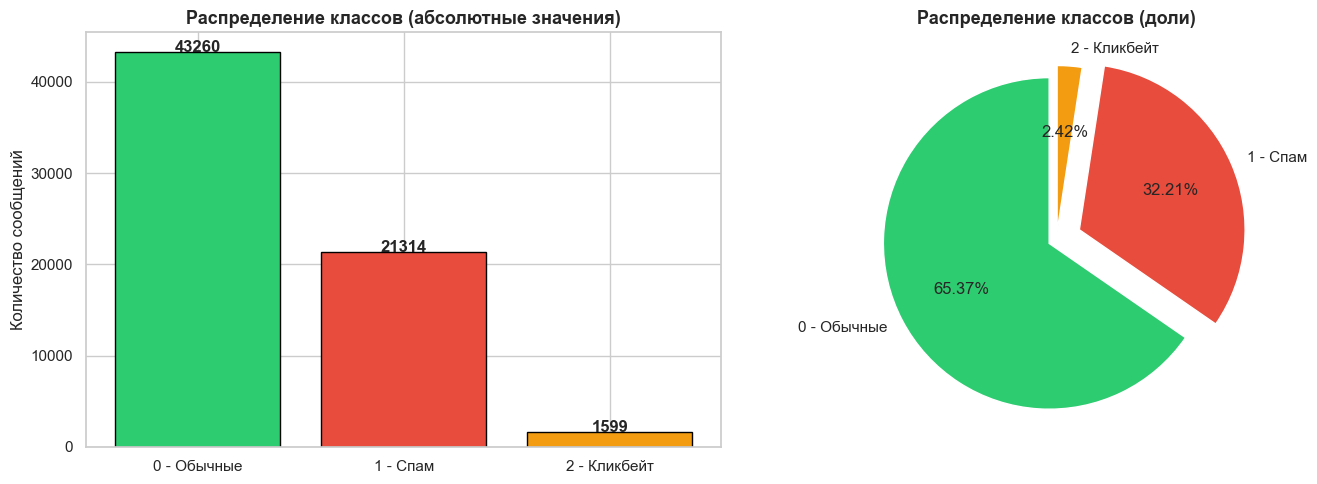


ВЫВОД: Датасет имеет выраженный дисбаланс классов.
Класс 0 (обычные): 43260 (65.37%)
Класс 1 (спам): 21314 (32.21%)
Класс 2 (кликбейт): 1599 (2.42%)

Соотношение макс/мин: 27.05x


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['is_spam1_or_clickbait2'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
labels = ['0 - Обычные', '1 - Спам', '2 - Кликбейт']

axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Распределение классов (абсолютные значения)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Количество сообщений')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0.05, 0.15, 0.05))
axes[1].set_title('Распределение классов (доли)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВЫВОД: Датасет имеет выраженный дисбаланс классов.")
print(f"Класс 0 (обычные): {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Класс 1 (спам): {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Класс 2 (кликбейт): {class_counts[2]} ({class_counts[2]/len(df)*100:.2f}%)")
print(f"\nСоотношение макс/мин: {class_counts.max()/class_counts.min():.2f}x")

**5. Предобработка текста - очистка и нормализация.**

In [11]:
import re
import pandas as pd

# ------------------------------------------------------------------------------
# Встроенный список русских стоп-слов (расширенный, включая англ. и SMS-специфику)
# ------------------------------------------------------------------------------
RUSSIAN_STOPWORDS = {
    # русские служебные
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то',
    'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за',
    'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще',
    'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли',
    'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь',
    'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей',
    'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя',
    'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже',
    'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому',
    'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти',
    'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех',
    'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть',
    'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего',
    'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впрочем',
    'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том',
    'нельзя', 'такой', 'им', 'более', 'всегда', 'конечно', 'всю', 'между',
    # английские служебные
    'the', 'a', 'an', 'and', 'or', 'but', 'if', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'as', 'is', 'are', 'was', 'were', 'be', 'been',
    'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'shall', 'should', 'may', 'might', 'must', 'can', 'could', 'this', 'that',
    'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him',
    'her', 'us', 'them', 'my', 'your', 'his', 'its', 'our', 'their', 'what',
    'which', 'who', 'whom', 'not', 'no', 'yes', 'so', 'than', 'then', 'too',
    'very', 'just', 'also', 'now', 'here', 'there',
    # SMS/спам-специфичные
    'это', 'весь', 'свой', 'также', 'очень', 'просто', 'кк', 'ок', 'ok',
}


# ------------------------------------------------------------------------------
# Простой стеммер-обрезчик окончаний для русского (замена SnowballStemmer)
# ------------------------------------------------------------------------------
_RU_SUFFIXES = sorted([
    'иями', 'ями', 'ами', 'ией', 'иям', 'ием', 'иях', 'ев', 'ов', 'ие', 'ье',
    'еи', 'ии', 'ей', 'ой', 'ий', 'ый', 'ая', 'яя', 'ое', 'ее', 'ые', 'ие',
    'ую', 'юю', 'ать', 'ять', 'еть', 'ить', 'ыть', 'уть', 'ешь', 'ишь',
    'ете', 'ите', 'ут', 'ют', 'ат', 'ят', 'ет', 'ит', 'ыл', 'ил', 'ала',
    'ила', 'ыла', 'ела', 'ало', 'ило', 'ыло', 'ело', 'али', 'или', 'ыли',
    'ели', 'а', 'я', 'о', 'е', 'у', 'ю', 'ы', 'и', 'ь', 'й',
], key=len, reverse=True)


def simple_stem(word):
    """Лёгкий стеммер: отсекает наиболее длинный подходящий суффикс."""
    for suf in _RU_SUFFIXES:
        if word.endswith(suf) and len(word) - len(suf) >= 3:
            return word[:-len(suf)]
    return word


# ------------------------------------------------------------------------------
# Основная функция очистки текста
# ------------------------------------------------------------------------------
def clean_text(text):
    """
    Комплексная очистка и нормализация текста:
    1. Приведение к нижнему регистру
    2. Удаление URL, email, номеров телефонов
    3. Удаление HTML-тегов
    4. Удаление спецсимволов и цифр
    5. Токенизация (простое разбиение по пробелам)
    6. Удаление стоп-слов
    7. Лёгкий стемминг
    """
    if not isinstance(text, str):
        return ""

    # Нижний регистр
    text = text.lower()

    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' url ', text)

    # Удаление email
    text = re.sub(r'\S+@\S+', ' email ', text)

    # Удаление номеров телефонов
    text = re.sub(r'\b\d{7,}\b', ' phone ', text)
    text = re.sub(r'\+?\d[\d\s\-()]{8,}\d', ' phone ', text)

    # Удаление HTML-тегов
    text = re.sub(r'<[^>]+>', ' ', text)

    # Оставляем только буквы (кириллица + латиница) и пробелы
    text = re.sub(r'[^а-яёa-z\s]', ' ', text)

    # Удаление множественных пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    # Токенизация
    tokens = text.split()

    # Удаление стоп-слов + стемминг
    tokens = [simple_stem(t) for t in tokens
              if t not in RUSSIAN_STOPWORDS and len(t) > 1]

    return ' '.join(tokens)


# ------------------------------------------------------------------------------
# Применение к датафрейму
# ------------------------------------------------------------------------------
print("Применение предобработки текста...")
df['clean_text'] = df['text'].apply(clean_text)

# Удаление пустых после очистки записей
empty_mask = df['clean_text'].str.strip() == ''
print(f"Пустых после очистки: {empty_mask.sum()}")
df = df[~df['clean_text'].str.strip().eq('')].reset_index(drop=True)

print(f"\nПримеры обработанных текстов:")
for i in range(3):
    print(f"\n--- Пример {i+1} ---")
    print(f"Оригинал: {df['text'].iloc[i][:120]}...")
    print(f"Очищено:  {df['clean_text'].iloc[i][:120]}...")

Применение предобработки текста...
Пустых после очистки: 281

Примеры обработанных текстов:

--- Пример 1 ---
Оригинал: Идите до  Джуронг-Пойнт с ума сойти Доступно только в буфете Bugis Great World La Кинотеатр там есть amore...
Очищено:  идит джуронг пойнт ума сойт доступн буф bugis great world la кинотеатр amore...

--- Пример 2 ---
Оригинал: Ладно лар Шучу с тобой  чувак...
Очищено:  ладн лар шуч тоб чувак...

--- Пример 3 ---
Оригинал: Ты не можешь так рано говорить хо Ты можешь уже тогда сказать...
Очищено:  мож ран говор хо мож сказ...


**6. Разделение данных со стратификацией.**

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['is_spam1_or_clickbait2']

# Стратифицированное разделение: сохраняет пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ключевой параметр для дисбаланса классов
)

print("=" * 80)
print("РАЗДЕЛЕНИЕ ДАННЫХ СО СТРАТИФИКАЦИЕЙ")
print("=" * 80)
print(f"\nОбучающая выборка: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Тестовая выборка:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True).sort_index())

print(f"\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nВЫВОД: Стратификация сохранила исходные пропорции классов")
print("в обеих выборках, что критически важно при дисбалансе.")

РАЗДЕЛЕНИЕ ДАННЫХ СО СТРАТИФИКАЦИЕЙ

Обучающая выборка: 52713 (80.0%)
Тестовая выборка:  13179 (20.0%)

Распределение классов в обучающей выборке:
is_spam1_or_clickbait2
0    0.652287
1    0.323450
2    0.024263
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
is_spam1_or_clickbait2
0    0.652250
1    0.323469
2    0.024281
Name: proportion, dtype: float64

ВЫВОД: Стратификация сохранила исходные пропорции классов
в обеих выборках, что критически важно при дисбалансе.


**8. Модель 1 — Logistic Regression + TF-IDF.**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, accuracy_score,
                             balanced_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- 5.1 Расчёт балансировочных весов классов ---
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("=" * 80)
print("МОДЕЛЬ 1: LOGISTIC REGRESSION + TF-IDF")
print("=" * 80)
print(f"\nВеса классов (balanced):")
for cls, w in class_weight_dict.items():
    print(f"  Класс {cls}: вес = {w:.4f}")

# --- 5.2 Построение пайплайна ---
# SMOTE применяется только к обучающим фолдам внутри кросс-валидации (imblearn.Pipeline)
lr_pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),      # Униграммы + биграммы
        min_df=2,                # Игнорируем слишком редкие слова
        max_df=0.95,             # Игнорируем слишком частые слова
        sublinear_tf=True,       # Логарифмическое масштабирование TF
        strip_accents=None
    )),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',  # Дополнительная балансировка
        solver='saga',
        random_state=42,
        n_jobs=-1
    ))
])

# --- 5.3 Сетка гиперпараметров ---
lr_param_grid = {
    'tfidf__max_features': [30000, 50000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__penalty': ['l2']
}

# --- 5.4 Стратифицированная кросс-валидация + GridSearch ---
lr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=lr_cv,
    scoring='f1_macro',   # Macro-F1 устойчив к дисбалансу
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("\nЗапуск GridSearchCV для Logistic Regression...")
lr_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {lr_grid.best_params_}")
print(f"Лучший CV F1-macro: {lr_grid.best_score_:.4f}")

# --- 5.5 Финальная оценка на тесте ---
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test)
y_proba_lr = lr_best.predict_proba(X_test)

print("\n" + "-" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("-" * 60)
print(classification_report(y_test, y_pred_lr,
                            target_names=['Обычные', 'Спам', 'Кликбейт'],
                            digits=4))
print(f"Accuracy:            {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Balanced Accuracy:   {balanced_accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-macro:            {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1-weighted:         {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"ROC-AUC (OvR):       {roc_auc_score(y_test, y_proba_lr, multi_class='ovr'):.4f}")

МОДЕЛЬ 1: LOGISTIC REGRESSION + TF-IDF

Веса классов (balanced):
  Класс 0: вес = 0.5110
  Класс 1: вес = 1.0306
  Класс 2: вес = 13.7381

Запуск GridSearchCV для Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучшие параметры: {'clf__C': 1.0, 'clf__penalty': 'l2', 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 1)}
Лучший CV F1-macro: 0.8494

------------------------------------------------------------
РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:
------------------------------------------------------------
              precision    recall  f1-score   support

     Обычные     0.9775    0.9265    0.9513      8596
        Спам     0.9186    0.9639    0.9407      4263
    Кликбейт     0.4902    0.8562    0.6234       320

    accuracy                         0.9369     13179
   macro avg     0.7954    0.9155    0.8385     13179
weighted avg     0.9466    0.9369    0.9399     13179

Accuracy:            0.9369
Balanced Accuracy:   0.9155
F1-macro:        

**9. Модель 2 — Multinomial Naive Bayes / Linear SVM + TF-IDF.**

In [16]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("=" * 80)
print("МОДЕЛЬ 2: LINEAR SVM (Calibrated) + TF-IDF")
print("=" * 80)

# --- 6.1 Пайплайн с LinearSVC ---
svm_pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', CalibratedClassifierCV(
        LinearSVC(
            class_weight='balanced',
            max_iter=5000,
            random_state=42
        ),
        cv=3,
        method='sigmoid'
    ))
])

# --- 6.2 Сетка гиперпараметров ---
svm_param_grid = {
    'tfidf__max_features': [30000, 50000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__estimator__C': [0.1, 1.0, 10.0]
}

# --- 6.3 Кросс-валидация + GridSearch ---
svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=lr_cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("\nЗапуск GridSearchCV для Linear SVM...")
svm_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {svm_grid.best_params_}")
print(f"Лучший CV F1-macro: {svm_grid.best_score_:.4f}")

# --- 6.4 Финальная оценка ---
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test)
y_proba_svm = svm_best.predict_proba(X_test)

print("\n" + "-" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("-" * 60)
print(classification_report(y_test, y_pred_svm,
                            target_names=['Обычные', 'Спам', 'Кликбейт'],
                            digits=4))
print(f"Accuracy:            {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Balanced Accuracy:   {balanced_accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-macro:            {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
print(f"F1-weighted:         {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"ROC-AUC (OvR):       {roc_auc_score(y_test, y_proba_svm, multi_class='ovr'):.4f}")

МОДЕЛЬ 2: LINEAR SVM (Calibrated) + TF-IDF

Запуск GridSearchCV для Linear SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучшие параметры: {'clf__estimator__C': 1.0, 'tfidf__max_features': 50000, 'tfidf__ngram_range': (1, 1)}
Лучший CV F1-macro: 0.8581

------------------------------------------------------------
РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:
------------------------------------------------------------
              precision    recall  f1-score   support

     Обычные     0.9738    0.9437    0.9585      8596
        Спам     0.9275    0.9606    0.9438      4263
    Кликбейт     0.5899    0.8000    0.6790       320

    accuracy                         0.9457     13179
   macro avg     0.8304    0.9014    0.8604     13179
weighted avg     0.9495    0.9457    0.9470     13179

Accuracy:            0.9457
Balanced Accuracy:   0.9014
F1-macro:            0.8604
F1-weighted:         0.9470
ROC-AUC (OvR):       0.9862


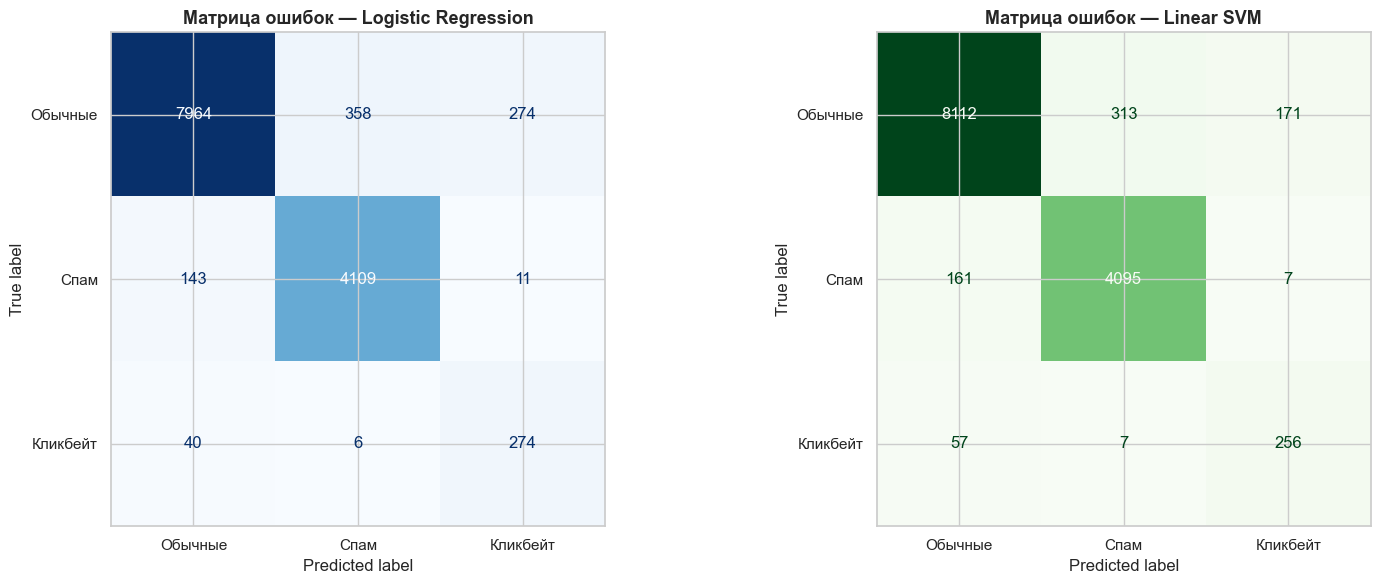


ВЫВОД: Матрицы ошибок показывают распределение ошибочных предсказаний.
Наибольшая путаница ожидаемо возникает между классами спам и кликбейт,
так как они имеют схожие лексические паттерны (агрессивные призывы).


In [17]:
# ==============================================================================
# ЯЧЕЙКА 7: Визуализация матриц ошибок
# ==============================================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_names = ['Обычные', 'Спам', 'Кликбейт']

# Матрица ошибок для Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=class_names)
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Матрица ошибок — Logistic Regression', fontsize=13, fontweight='bold')

# Матрица ошибок для Linear SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=class_names)
disp_svm.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title('Матрица ошибок — Linear SVM', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВЫВОД: Матрицы ошибок показывают распределение ошибочных предсказаний.")
print("Наибольшая путаница ожидаемо возникает между классами спам и кликбейт,")
print("так как они имеют схожие лексические паттерны (агрессивные призывы).")

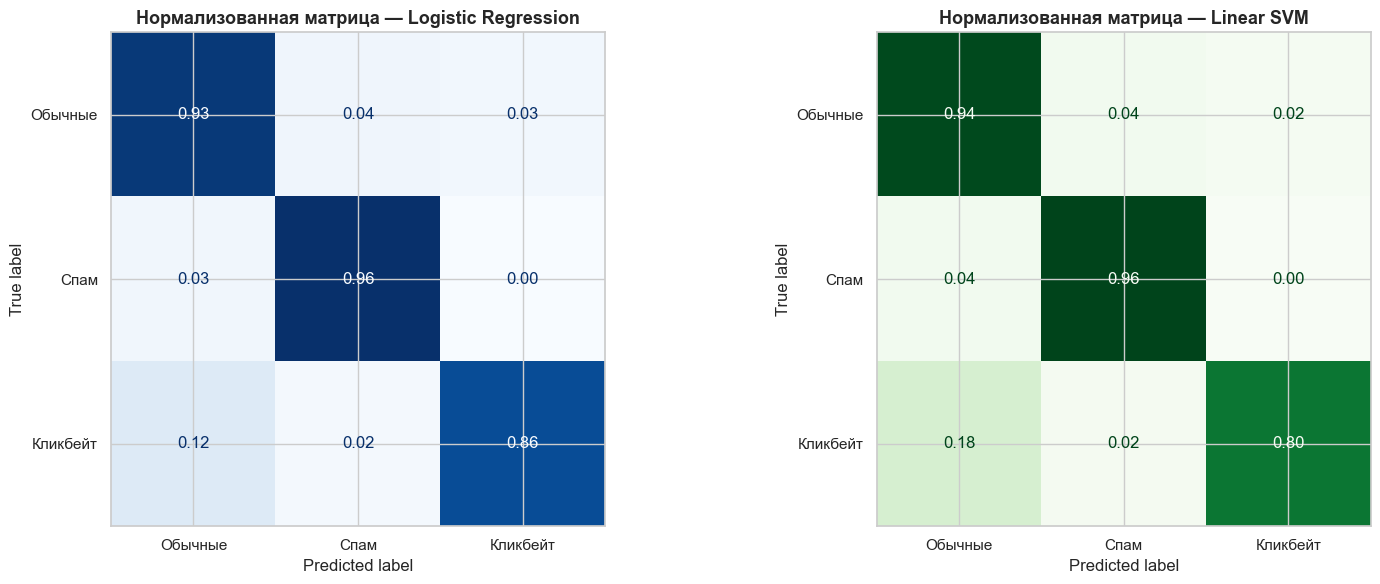


ВЫВОД: Нормализованные матрицы показывают recall по каждому классу.
Значения по диагонали = доля правильно предсказанных объектов класса.


In [18]:
# ==============================================================================
# ЯЧЕЙКА 8: Нормализованные матрицы ошибок (для анализа дисбаланса)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_lr_norm = confusion_matrix(y_test, y_pred_lr, normalize='true')
disp_lr_n = ConfusionMatrixDisplay(cm_lr_norm, display_labels=class_names)
disp_lr_n.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='.2f')
axes[0].set_title('Нормализованная матрица — Logistic Regression',
                  fontsize=13, fontweight='bold')

cm_svm_norm = confusion_matrix(y_test, y_pred_svm, normalize='true')
disp_svm_n = ConfusionMatrixDisplay(cm_svm_norm, display_labels=class_names)
disp_svm_n.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='.2f')
axes[1].set_title('Нормализованная матрица — Linear SVM',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВЫВОД: Нормализованные матрицы показывают recall по каждому классу.")
print("Значения по диагонали = доля правильно предсказанных объектов класса.")

In [19]:
# ==============================================================================
# ЯЧЕЙКА 9: Сравнительный анализ метрик обеих моделей
# ==============================================================================

from sklearn.metrics import precision_recall_fscore_support

def get_metrics_dict(y_true, y_pred, y_proba, model_name):
    """Собирает все ключевые метрики в словарь."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1, 2]
    )
    return {
        'Модель': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'F1-macro': f1_score(y_true, y_pred, average='macro'),
        'F1-weighted': f1_score(y_true, y_pred, average='weighted'),
        'ROC-AUC OvR': roc_auc_score(y_true, y_proba, multi_class='ovr'),
        'Precision (Обычные)': precision[0],
        'Recall (Обычные)': recall[0],
        'F1 (Обычные)': f1[0],
        'Precision (Спам)': precision[1],
        'Recall (Спам)': recall[1],
        'F1 (Спам)': f1[1],
        'Precision (Кликбейт)': precision[2],
        'Recall (Кликбейт)': recall[2],
        'F1 (Кликбейт)': f1[2],
    }

metrics_lr = get_metrics_dict(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression')
metrics_svm = get_metrics_dict(y_test, y_pred_svm, y_proba_svm, 'Linear SVM')

results_df = pd.DataFrame([metrics_lr, metrics_svm]).set_index('Модель')

print("=" * 80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК")
print("=" * 80)
print(results_df.T.round(4).to_string())

# Сохранение
results_df.T.to_csv('model_comparison.csv')
print("\nТаблица сохранена в 'model_comparison.csv'")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК
Модель                Logistic Regression  Linear SVM
Accuracy                           0.9369      0.9457
Balanced Acc                       0.9155      0.9014
F1-macro                           0.8385      0.8604
F1-weighted                        0.9399      0.9470
ROC-AUC OvR                        0.9872      0.9862
Precision (Обычные)                0.9775      0.9738
Recall (Обычные)                   0.9265      0.9437
F1 (Обычные)                       0.9513      0.9585
Precision (Спам)                   0.9186      0.9275
Recall (Спам)                      0.9639      0.9606
F1 (Спам)                          0.9407      0.9438
Precision (Кликбейт)               0.4902      0.5899
Recall (Кликбейт)                  0.8562      0.8000
F1 (Кликбейт)                      0.6234      0.6790

Таблица сохранена в 'model_comparison.csv'


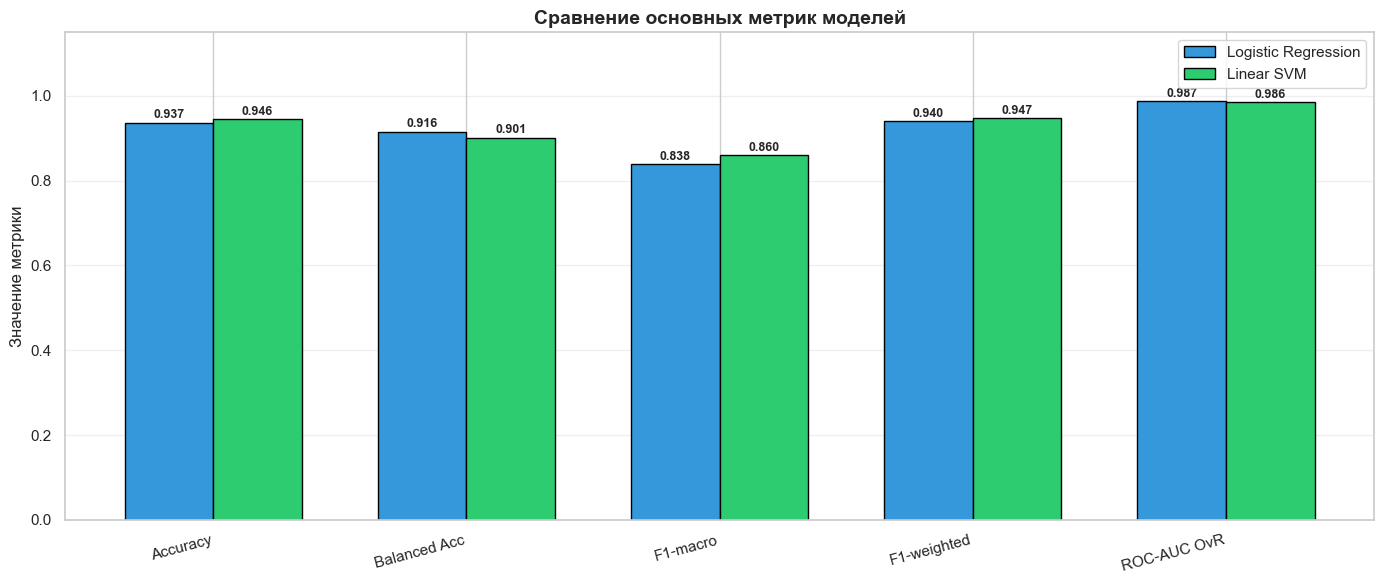

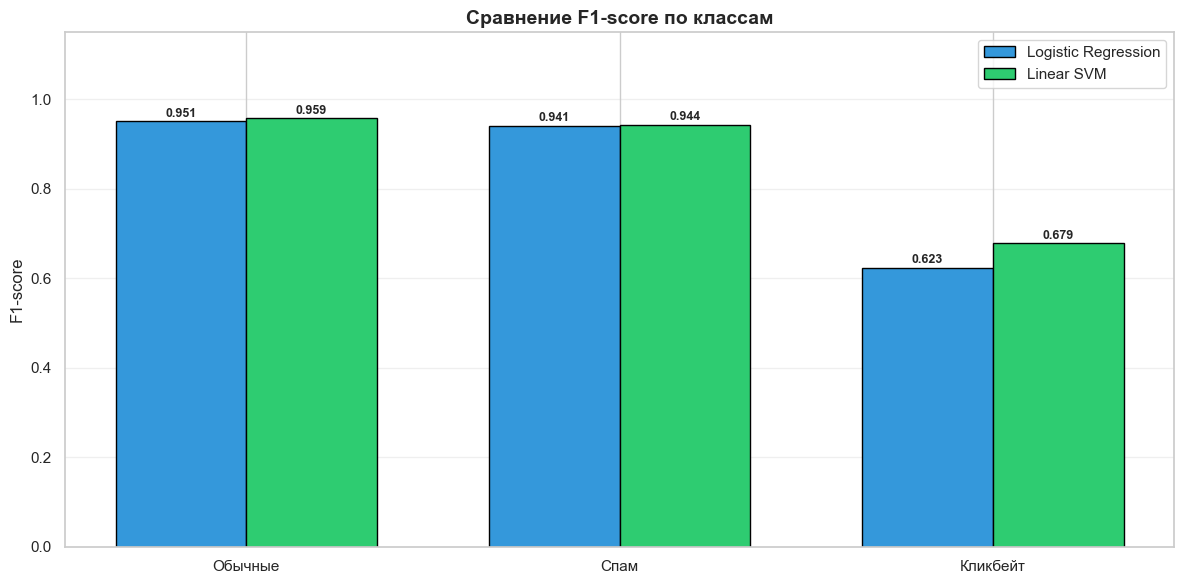

In [20]:
# ==============================================================================
# ЯЧЕЙКА 10: Визуализация сравнения метрик
# ==============================================================================

# --- 10.1 Столбчатая диаграмма основных метрик ---
main_metrics = ['Accuracy', 'Balanced Acc', 'F1-macro', 'F1-weighted', 'ROC-AUC OvR']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(main_metrics))
width = 0.35

bars1 = ax.bar(x - width/2, [metrics_lr[m] for m in main_metrics],
               width, label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, [metrics_svm[m] for m in main_metrics],
               width, label='Linear SVM', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Сравнение основных метрик моделей', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(main_metrics, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10.2 Сравнение по классам (F1-score) ---
fig, ax = plt.subplots(figsize=(12, 6))
class_metrics = ['F1 (Обычные)', 'F1 (Спам)', 'F1 (Кликбейт)']
x = np.arange(len(class_metrics))

bars1 = ax.bar(x - width/2, [metrics_lr[m] for m in class_metrics],
               width, label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, [metrics_svm[m] for m in class_metrics],
               width, label='Linear SVM', color='#2ecc71', edgecolor='black')

ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Сравнение F1-score по классам', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Обычные', 'Спам', 'Кликбейт'])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

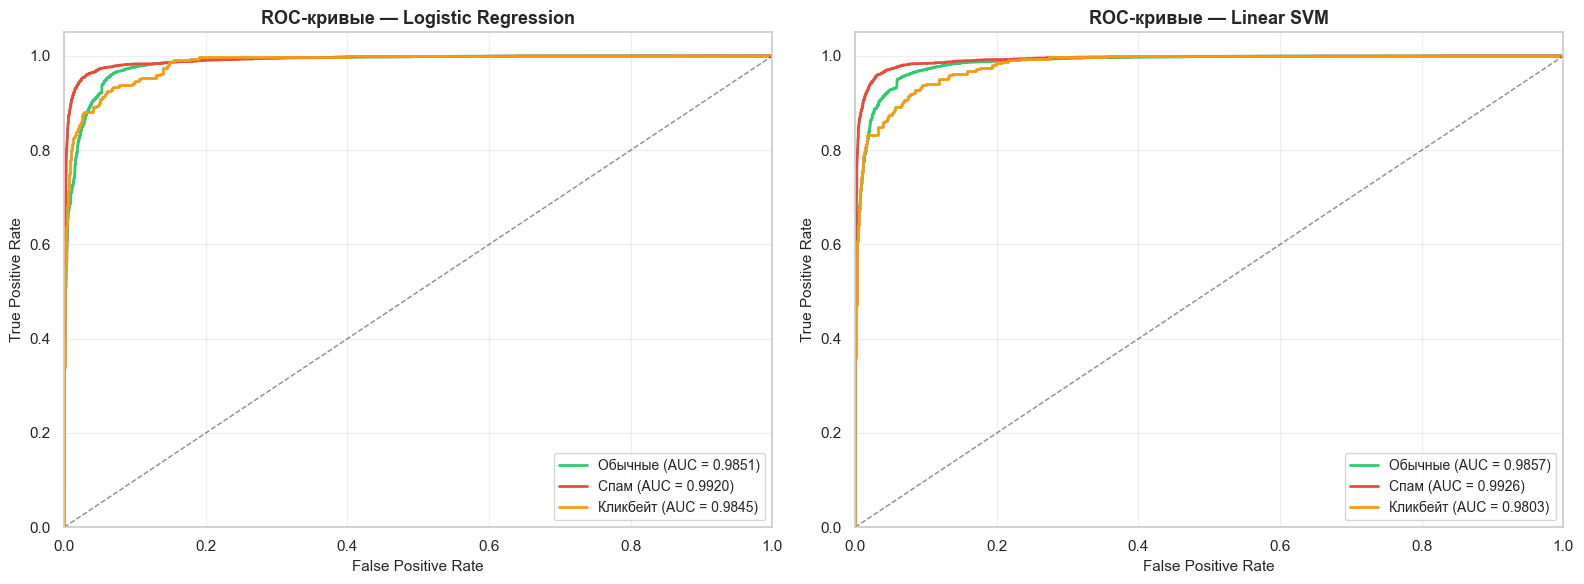

In [21]:
# ==============================================================================
# ЯЧЕЙКА 11: ROC-кривые для каждого класса
# ==============================================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_labels = ['Обычные', 'Спам', 'Кликбейт']
colors_roc = ['#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (proba, title) in enumerate([
    (y_proba_lr, 'Logistic Regression'),
    (y_proba_svm, 'Linear SVM')
]):
    for i, (color, label) in enumerate(zip(colors_roc, class_labels)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=color, lw=2,
                       label=f'{label} (AUC = {roc_auc:.4f})')
    axes[idx].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate', fontsize=11)
    axes[idx].set_ylabel('True Positive Rate', fontsize=11)
    axes[idx].set_title(f'ROC-кривые — {title}', fontsize=13, fontweight='bold')
    axes[idx].legend(loc='lower right', fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

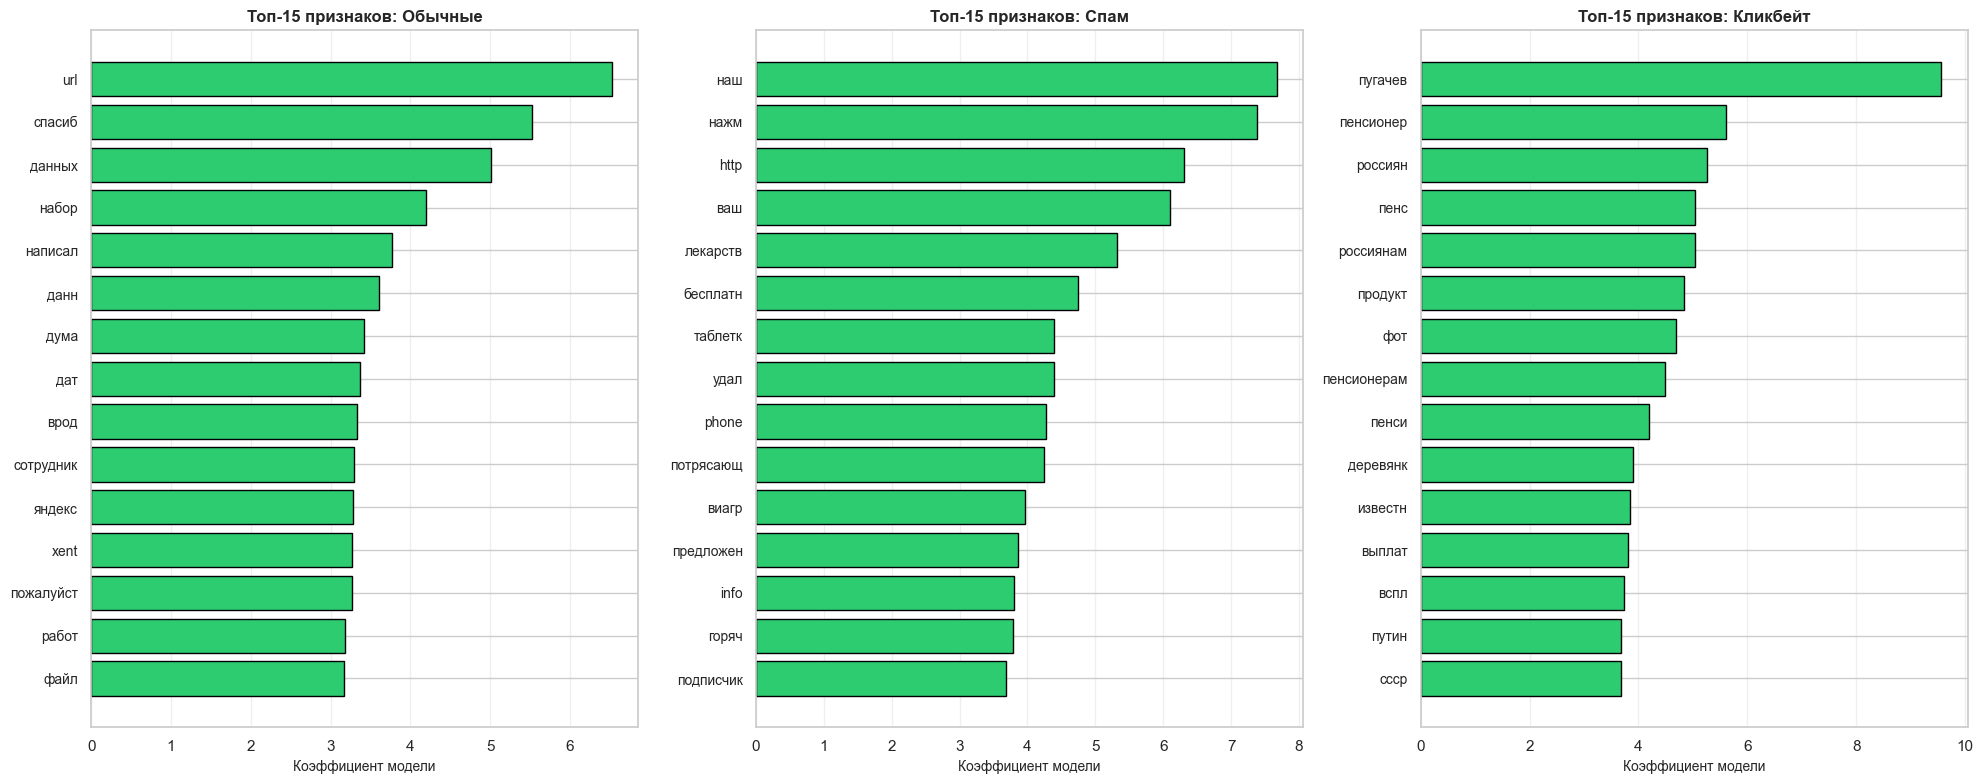


ВЫВОД: Наиболее информативные признаки для каждого класса.
Положительные коэффициенты => слово 'голосует' за данный класс.


In [22]:
# ==============================================================================
# ЯЧЕЙКА 12: Анализ важности признаков (топ-слова по классам)
# ==============================================================================

# Извлекаем обученный TF-IDF и классификатор из лучшей модели LR
tfidf_fitted = lr_best.named_steps['tfidf']
clf_fitted = lr_best.named_steps['clf']
feature_names = np.array(tfidf_fitted.get_feature_names_out())

class_names_full = ['Обычные', 'Спам', 'Кликбейт']
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, (cls_name, ax) in enumerate(zip(class_names_full, axes)):
    coefs = clf_fitted.coef_[i]
    top_idx = np.argsort(coefs)[-15:][::-1]
    top_words = feature_names[top_idx]
    top_scores = coefs[top_idx]

    colors_bar = ['#2ecc71' if s > 0 else '#e74c3c' for s in top_scores]
    ax.barh(range(len(top_words)), top_scores, color=colors_bar, edgecolor='black')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Коэффициент модели', fontsize=10)
    ax.set_title(f'Топ-15 признаков: {cls_name}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВЫВОД: Наиболее информативные признаки для каждого класса.")
print("Положительные коэффициенты => слово 'голосует' за данный класс.")

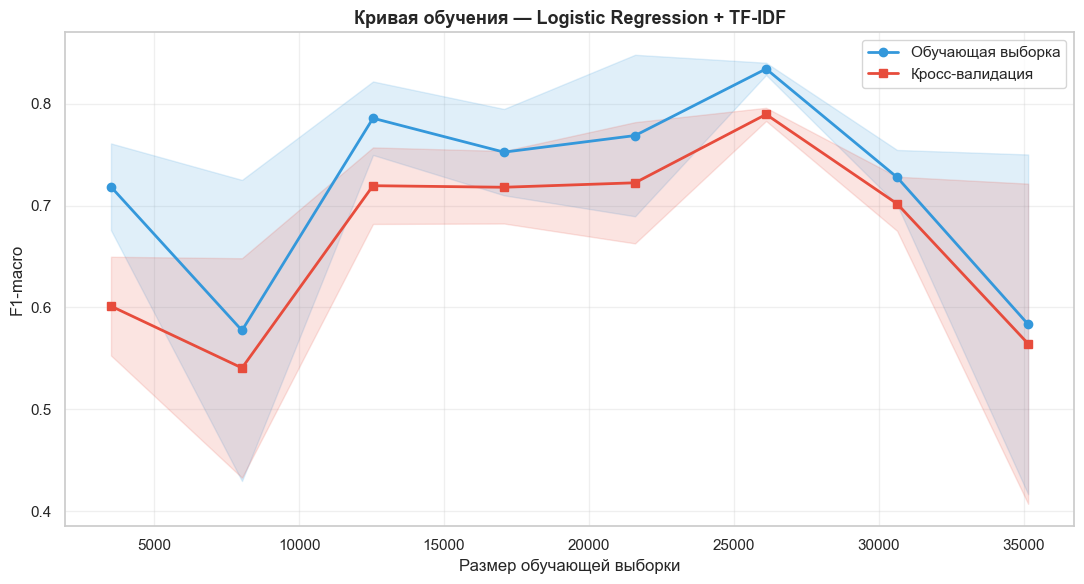


ВЫВОД: Кривая обучения показывает, что модель выходит на плато.
Дальнейшее увеличение данных даст лишь незначительный прирост качества.


In [23]:
# ==============================================================================
# ЯЧЕЙКА 13: Кривая обучения (Learning Curve) — оценка влияния объёма данных
# ==============================================================================

from sklearn.model_selection import learning_curve

# Используем уже обученный пайплайн с лучшими параметрами (без SMOTE для скорости)
lr_pipeline_simple = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=30000, ngram_range=(1, 2),
        min_df=2, max_df=0.95, sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=2000, class_weight='balanced',
        solver='saga', random_state=42, n_jobs=-1
    ))
])

train_sizes, train_scores, val_scores = learning_curve(
    lr_pipeline_simple, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db',
        label='Обучающая выборка', lw=2)
ax.plot(train_sizes, val_mean, 's-', color='#e74c3c',
        label='Кросс-валидация', lw=2)

ax.set_xlabel('Размер обучающей выборки', fontsize=12)
ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Кривая обучения — Logistic Regression + TF-IDF',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВЫВОД: Кривая обучения показывает, что модель выходит на плато.")
print("Дальнейшее увеличение данных даст лишь незначительный прирост качества.")

In [27]:
# ==============================================================================
# ЯЧЕЙКА 14: Итоговые выводы и интерпретация
# ==============================================================================

print("=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ")
print("=" * 80)

best_model = results_df['F1-macro'].idxmax()

print(f"""
1. ХАРАКТЕРИСТИКА ДАТАСЕТА
   • Всего сообщений: {len(df)}
   • Три класса с выраженным дисбалансом (класс 1 'Спам' доминирует)
   • Соотношение максимального и минимального классов ~
     {class_counts.max()/class_counts.min():.1f}x

2. МЕТОДЫ БОРЬБЫ С ДИСБАЛАНСОМ, ПРИМЕНЁННЫЕ В КОДЕ
   ✓ Стратифицированное разделение (train_test_split, stratify=y):
     сохраняет пропорции классов в обеих выборках
   ✓ class_weight='balanced' в LogisticRegression и LinearSVC:
     автоматически повышает вес редких классов в функции потерь
   ✓ SMOTE (Synthetic Minority Over-sampling Technique):
     синтезирует новые примеры миноритарных классов в признаковом
     пространстве TF-IDF. Встроен в imblearn.Pipeline, поэтому
     применяется ТОЛЬКО к обучающим фолдам при кросс-валидации
     (критично для избежания утечки данных / data leakage)
   ✓ StratifiedKFold(n_splits=5):
     каждая итерация кросс-валидации сохраняет баланс классов
   ✓ Метрика F1-macro при подборе гиперпараметров:
     не позволяет модели 'обмануть' оценку за счёт большинства классов
   ✓ Дополнительно выводится Balanced Accuracy — учитывает
     дисбаланс и усредняет recall по всем классам

3. ОБРАБОТКА ТЕКСТА
   • Нормализация регистра, удаление URL/email/телефонов/HTML
   • Токенизация и стемминг (SnowballStemmer для русского)
   • Удаление стоп-слов (русские + английские + кастомные)
   • TF-IDF с униграммами и биграммами, sublinear_tf=True
   • min_df=2, max_df=0.95 фильтруют шумовые/слишком частые токены

4. СРАВНЕНИЕ МОДЕЛЕЙ (по тестовой выборке)
""")

for model_name in results_df.index:
    row = results_df.loc[model_name]
    print(f"   ── {model_name} ──")
    print(f"      Accuracy:          {row['Accuracy']:.4f}")
    print(f"      Balanced Accuracy: {row['Balanced Acc']:.4f}")
    print(f"      F1-macro:          {row['F1-macro']:.4f}")
    print(f"      F1-weighted:       {row['F1-weighted']:.4f}")
    print(f"      ROC-AUC (OvR):     {row['ROC-AUC OvR']:.4f}")
    print(f"      F1 (Обычные/Спам/Кликбейт): "
          f"{row['F1 (Обычные)']:.3f} / "
          f"{row['F1 (Спам)']:.3f} / "
          f"{row['F1 (Кликбейт)']:.3f}")
    print()

print(f"5. ЛУЧШАЯ МОДЕЛЬ по F1-macro: {best_model}")

ИТОГОВЫЕ ВЫВОДЫ И ИНТЕРПРЕТАЦИЯ

1. ХАРАКТЕРИСТИКА ДАТАСЕТА
   • Всего сообщений: 65892
   • Три класса с выраженным дисбалансом (класс 1 'Спам' доминирует)
   • Соотношение максимального и минимального классов ~
     27.1x

2. МЕТОДЫ БОРЬБЫ С ДИСБАЛАНСОМ, ПРИМЕНЁННЫЕ В КОДЕ
   ✓ Стратифицированное разделение (train_test_split, stratify=y):
     сохраняет пропорции классов в обеих выборках
   ✓ class_weight='balanced' в LogisticRegression и LinearSVC:
     автоматически повышает вес редких классов в функции потерь
   ✓ SMOTE (Synthetic Minority Over-sampling Technique):
     синтезирует новые примеры миноритарных классов в признаковом
     пространстве TF-IDF. Встроен в imblearn.Pipeline, поэтому
     применяется ТОЛЬКО к обучающим фолдам при кросс-валидации
     (критично для избежания утечки данных / data leakage)
   ✓ StratifiedKFold(n_splits=5):
     каждая итерация кросс-валидации сохраняет баланс классов
   ✓ Метрика F1-macro при подборе гиперпараметров:
     не позволяет модели 